# Accelerated Layer Normalization with Custom GPU Kernels

```
╔══════════════════════════════════════════════════════════════════════╗
║                     WORKSHOP LEARNING OBJECTIVES                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  → Build production-grade LayerNorm kernels beating PyTorch          ║
║  → Master backward pass implementation in Triton                      ║
║  → Understand parallel reduction patterns for gradient accumulation   ║
╚══════════════════════════════════════════════════════════════════════╝
```
Notebook is inspired and made based on work from @Twonadorable


---

## Section 1: Mathematical Foundation

### What is Layer Normalization?

Layer Normalization *(Ba et al., 2016)* is a critical building block in modern architectures like Transformers. Unlike Batch Normalization, it normalizes across the **feature dimension** rather than the batch dimension, making it ideal for:

| Use Case | Why LayerNorm? |
|----------|----------------|
| **Transformers** | Variable sequence lengths |
| **Small batches** | No batch statistics needed |
| **RNNs/LSTMs** | Per-timestep normalization |

### Forward Pass Mathematics

Given input vector $\mathbf{x} \in \mathbb{R}^N$, weights $\mathbf{w}$, and biases $\mathbf{b}$:

$$\mathbf{y} = \frac{\mathbf{x} - \mu}{\sigma} \odot \mathbf{w} + \mathbf{b}$$

where:
- $\mu = \frac{1}{N}\sum_{i=1}^{N} x_i$ (mean)
- $\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2 + \epsilon}$ (standard deviation)
- $\epsilon$ is a small constant for numerical stability

### Forward Pass Implementation
of sequential models (e.g., Transformers) or neural networks with small batch size.
It takes a vector $x$ as input and produces a vector $y$ of the same shape as output.
The normalization is performed by subtracting the mean and dividing by the standard deviation of $x$.
After the normalization, a learnable linear transformation with weights $w$ and biases $b$ is applied.
The forward pass can be expressed as follows:

\begin{align}y = \frac{ x - \text{E}[x] }{ \sqrt{\text{Var}(x) + \epsilon} } * w + b\end{align}

where $\epsilon$ is a small constant added to the denominator for numerical stability.
Let’s first take a look at the forward pass implementation.



In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                         DEPENDENCY IMPORTS                                 ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

import torch
import triton
import triton.language as tl

# Attempt to load NVIDIA Apex for comparison benchmarks
# Note: This is the GitHub version, not PyPI apex
try:
    import apex
    APEX_AVAILABLE = True
except ModuleNotFoundError:
    APEX_AVAILABLE = False

# Initialize compute device
COMPUTE_DEVICE = triton.runtime.driver.active.get_active_torch_device()

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                    FORWARD PASS KERNEL IMPLEMENTATION                      ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

@triton.jit
def layer_norm_forward_kernel(
    # === Tensor Pointers ===
    input_ptr,           # Source data pointer
    output_ptr,          # Destination data pointer  
    gamma_ptr,           # Scale parameters (weights)
    beta_ptr,            # Shift parameters (biases)
    # === Statistics Storage ===
    mean_cache_ptr,      # Cache mean for backward pass
    rstd_cache_ptr,      # Cache 1/std for backward pass
    # === Tensor Layout ===
    row_stride,          # Elements between consecutive rows
    feature_dim,         # Number of features (N)
    # === Numerical Stability ===
    epsilon,             # Division safety constant
    # === Compile-Time Config ===
    TILE_SIZE: tl.constexpr,
):
    """
    Fused Layer Normalization Forward Pass
    
    Each program instance handles one complete row:
    1. Compute running sum for mean
    2. Compute running sum of squared deviations for variance
    3. Apply normalization with affine transformation
    """
    # Identify which row this program processes
    current_row = tl.program_id(0)
    
    # Advance pointers to current row
    output_ptr += current_row * row_stride
    input_ptr += current_row * row_stride
    
    # ─────────────────────────────────────────────────────────────────────────
    # PHASE 1: Compute Mean (Online Algorithm)
    # ─────────────────────────────────────────────────────────────────────────
    running_sum = tl.zeros([TILE_SIZE], dtype=tl.float32)
    
    for tile_start in range(0, feature_dim, TILE_SIZE):
        col_indices = tile_start + tl.arange(0, TILE_SIZE)
        valid_mask = col_indices < feature_dim
        tile_data = tl.load(input_ptr + col_indices, mask=valid_mask, other=0.).to(tl.float32)
        running_sum += tile_data
    
    row_mean = tl.sum(running_sum, axis=0) / feature_dim
    
    # ─────────────────────────────────────────────────────────────────────────
    # PHASE 2: Compute Variance
    # ─────────────────────────────────────────────────────────────────────────
    running_sq_diff = tl.zeros([TILE_SIZE], dtype=tl.float32)
    
    for tile_start in range(0, feature_dim, TILE_SIZE):
        col_indices = tile_start + tl.arange(0, TILE_SIZE)
        valid_mask = col_indices < feature_dim
        tile_data = tl.load(input_ptr + col_indices, mask=valid_mask, other=0.).to(tl.float32)
        centered = tl.where(valid_mask, tile_data - row_mean, 0.)
        running_sq_diff += centered * centered
    
    row_variance = tl.sum(running_sq_diff, axis=0) / feature_dim
    inv_std = 1 / tl.sqrt(row_variance + epsilon)
    
    # Cache statistics for backward pass
    tl.store(mean_cache_ptr + current_row, row_mean)
    tl.store(rstd_cache_ptr + current_row, inv_std)
    
    # ─────────────────────────────────────────────────────────────────────────
    # PHASE 3: Normalize and Apply Affine Transform
    # ─────────────────────────────────────────────────────────────────────────
    for tile_start in range(0, feature_dim, TILE_SIZE):
        col_indices = tile_start + tl.arange(0, TILE_SIZE)
        valid_mask = col_indices < feature_dim
        
        # Load affine parameters
        gamma = tl.load(gamma_ptr + col_indices, mask=valid_mask)
        beta = tl.load(beta_ptr + col_indices, mask=valid_mask)
        
        # Load and normalize input
        x_val = tl.load(input_ptr + col_indices, mask=valid_mask, other=0.).to(tl.float32)
        normalized = (x_val - row_mean) * inv_std
        
        # Apply affine transformation: y = gamma * x_norm + beta
        result = normalized * gamma + beta
        
        # Store output
        tl.store(output_ptr + col_indices, result, mask=valid_mask)

---

##  Section 2: Backward Pass Theory

### Gradient Derivation

The backward pass computes three gradients: $\nabla_{\mathbf{x}}$, $\nabla_{\mathbf{w}}$, and $\nabla_{\mathbf{b}}$.

#### Input Gradient ($\nabla_{\mathbf{x}}$)

Let $\hat{\mathbf{x}} = \frac{\mathbf{x} - \mu}{\sigma}$ be the normalized input. The VJP is:

$$\nabla_{\mathbf{x}} = \frac{1}{\sigma}\left( \nabla_{\mathbf{y}} \odot \mathbf{w} - c_1 \odot \hat{\mathbf{x}} - c_2 \right)$$

where:
- $c_1 = \frac{1}{N} \hat{\mathbf{x}} \cdot (\nabla_{\mathbf{y}} \odot \mathbf{w})$ — covariance correction
- $c_2 = \frac{1}{N} \nabla_{\mathbf{y}} \cdot \mathbf{w}$ — mean correction

#### Parameter Gradients

$$\nabla_{\mathbf{w}} = \sum_{\text{batch}} \nabla_{\mathbf{y}} \odot \hat{\mathbf{x}} \qquad \nabla_{\mathbf{b}} = \sum_{\text{batch}} \nabla_{\mathbf{y}}$$

### Parallel Reduction Strategy

```
┌──────────────────────────────────────────────────────────────────────────┐
│  STAGE 1: Per-Row Gradient Computation with Partial Accumulation         │
│  ────────────────────────────────────────────────────────────────────────│
│  • Each kernel computes dx for its row                                   │
│  • Partial dw/db accumulated into GROUP_SIZE_M buffers                   │
│  • Atomic locks prevent write conflicts                                  │
├──────────────────────────────────────────────────────────────────────────┤
│  STAGE 2: Final Reduction                                                │
│  ────────────────────────────────────────────────────────────────────────│
│  • Separate kernel reduces partial buffers                               │
│  • Produces final dw and db tensors                                      │
└──────────────────────────────────────────────────────────────────────────┘
```



In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                    BACKWARD PASS KERNEL: INPUT GRADIENT                    ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

@triton.jit
def layer_norm_backward_dx_kernel(
    # === Gradient Tensors ===
    grad_input_ptr,        # Output: gradient w.r.t. input
    grad_output_ptr,       # Input: upstream gradient
    partial_dw_ptr,        # Output: partial weight gradients
    partial_db_ptr,        # Output: partial bias gradients
    # === Forward Pass Data ===
    input_ptr,             # Original input tensor
    gamma_ptr,             # Weight parameters
    # === Cached Statistics ===
    mean_ptr,              # Cached mean from forward
    rstd_ptr,              # Cached 1/std from forward
    # === Synchronization ===
    lock_ptr,              # Mutex for atomic accumulation
    # === Layout Info ===
    row_stride,            # Stride between rows
    feature_dim,           # Feature dimension N
    # === Compile-Time Constants ===
    NUM_GROUPS: tl.constexpr,
    FEATURE_BLOCK: tl.constexpr
):
    """
    Stage 1: Compute input gradient and accumulate partial parameter gradients.
    
    Uses lock-based synchronization for safe parallel accumulation into
    shared gradient buffers.
    """
    # Identify row assignment
    current_row = tl.program_id(0)
    feature_indices = tl.arange(0, FEATURE_BLOCK)
    valid_features = feature_indices < feature_dim
    
    # Advance pointers to current row
    input_ptr += current_row * row_stride
    grad_output_ptr += current_row * row_stride
    grad_input_ptr += current_row * row_stride
    
    # Determine which reduction group this row belongs to
    group_id = current_row % NUM_GROUPS
    lock_ptr += group_id
    counter_ptr = lock_ptr + NUM_GROUPS
    partial_dw_ptr = partial_dw_ptr + group_id * feature_dim + feature_indices
    partial_db_ptr = partial_db_ptr + group_id * feature_dim + feature_indices
    
    # ─────────────────────────────────────────────────────────────────────────
    # Load Required Data into Registers
    # ─────────────────────────────────────────────────────────────────────────
    x_data = tl.load(input_ptr + feature_indices, mask=valid_features, other=0).to(tl.float32)
    dy_data = tl.load(grad_output_ptr + feature_indices, mask=valid_features, other=0).to(tl.float32)
    gamma = tl.load(gamma_ptr + feature_indices, mask=valid_features).to(tl.float32)
    row_mean = tl.load(mean_ptr + current_row)
    row_rstd = tl.load(rstd_ptr + current_row)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Compute Input Gradient (dx)
    # ─────────────────────────────────────────────────────────────────────────
    x_normalized = (x_data - row_mean) * row_rstd
    weighted_grad = gamma * dy_data
    
    # Apply masking for partial sums
    x_normalized = tl.where(valid_features, x_normalized, 0.)
    weighted_grad = tl.where(valid_features, weighted_grad, 0.)
    
    # Compute correction terms
    covar_correction = tl.sum(x_normalized * weighted_grad, axis=0) / feature_dim
    mean_correction = tl.sum(weighted_grad, axis=0) / feature_dim
    
    # Final gradient computation
    dx = (weighted_grad - (x_normalized * covar_correction + mean_correction)) * row_rstd
    tl.store(grad_input_ptr + feature_indices, dx, mask=valid_features)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Accumulate Partial Parameter Gradients (Atomic Section)
    # ─────────────────────────────────────────────────────────────────────────
    local_dw = (dy_data * x_normalized).to(gamma.dtype)
    local_db = (dy_data).to(gamma.dtype)
    
    # Acquire lock (spin until available)
    while tl.atomic_cas(lock_ptr, 0, 1) == 1:
        pass
    
    # Check if this is first write to buffer
    write_count = tl.load(counter_ptr)
    if write_count == 0:
        tl.atomic_xchg(counter_ptr, 1)
    else:
        # Accumulate with existing partial sums
        local_dw += tl.load(partial_dw_ptr, mask=valid_features)
        local_db += tl.load(partial_db_ptr, mask=valid_features)
    
    tl.store(partial_dw_ptr, local_dw, mask=valid_features)
    tl.store(partial_db_ptr, local_db, mask=valid_features)
    
    # Ensure all stores complete before releasing lock
    tl.debug_barrier()
    tl.atomic_xchg(lock_ptr, 0)


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                    BACKWARD PASS KERNEL: FINAL REDUCTION                   ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

@triton.jit
def layer_norm_backward_dwdb_kernel(
    # === Partial Gradients ===
    partial_dw_ptr,        # Input: partial weight gradients
    partial_db_ptr,        # Input: partial bias gradients
    # === Final Outputs ===
    final_dw_ptr,          # Output: reduced weight gradient
    final_db_ptr,          # Output: reduced bias gradient
    # === Dimensions ===
    num_groups,            # Number of accumulation groups
    feature_dim,           # Feature dimension N
    # === Block Sizes ===
    GROUP_BLOCK: tl.constexpr,
    FEATURE_BLOCK: tl.constexpr
):
    """
    Stage 2: Reduce partial gradient buffers to final parameter gradients.
    """
    program_idx = tl.program_id(0)
    feature_indices = program_idx * FEATURE_BLOCK + tl.arange(0, FEATURE_BLOCK)
    
    # Accumulators for reduction
    dw_accumulator = tl.zeros((GROUP_BLOCK, FEATURE_BLOCK), dtype=tl.float32)
    db_accumulator = tl.zeros((GROUP_BLOCK, FEATURE_BLOCK), dtype=tl.float32)
    
    # Sum across all groups
    for group_start in range(0, num_groups, GROUP_BLOCK):
        group_indices = group_start + tl.arange(0, GROUP_BLOCK)
        access_mask = (group_indices[:, None] < num_groups) & (feature_indices[None, :] < feature_dim)
        linear_offsets = group_indices[:, None] * feature_dim + feature_indices[None, :]
        
        dw_accumulator += tl.load(partial_dw_ptr + linear_offsets, mask=access_mask, other=0.)
        db_accumulator += tl.load(partial_db_ptr + linear_offsets, mask=access_mask, other=0.)
    
    # Final reduction across group dimension
    reduced_dw = tl.sum(dw_accumulator, axis=0)
    reduced_db = tl.sum(db_accumulator, axis=0)
    
    # Store final gradients
    tl.store(final_dw_ptr + feature_indices, reduced_dw, mask=feature_indices < feature_dim)
    tl.store(final_db_ptr + feature_indices, reduced_db, mask=feature_indices < feature_dim)

---

## Section 3: PyTorch Integration & Testing

### Custom Autograd Function

We wrap our kernels in a `torch.autograd.Function` to seamlessly integrate with PyTorch's automatic differentiation system.



layer-norm-backward:
          N      Triton       Torch
0    1024.0  143.982420  130.832143
1    1536.0  219.919469  122.344738
2    2048.0  222.061834  119.946919
3    2560.0  203.443708  113.207809
4    3072.0  178.342727  104.813348
5    3584.0  148.792475   99.161033
6    4096.0  121.456676  101.238329
7    4608.0  157.594588   99.096774
8    5120.0  134.134741   98.356866
9    5632.0  116.182971   98.232558
10   6144.0  106.697536   98.209882
11   6656.0  103.375355   98.319124
12   7168.0  101.539670   96.538723
13   7680.0  101.121933   95.180492
14   8192.0  100.721313   99.902435
15   8704.0  113.653970   95.206974
16   9216.0  108.470887   93.507832
17   9728.0  105.716688   94.118218
18  10240.0  103.631295   95.697442
19  10752.0  102.578088   95.831768
20  11264.0  102.408487   95.596340
21  11776.0  102.175565   95.095557
22  12288.0  102.193196   97.266490
23  12800.0  102.061392   94.944852
24  13312.0  101.863340   93.989520
25  13824.0  101.919301   91.940127
26  143

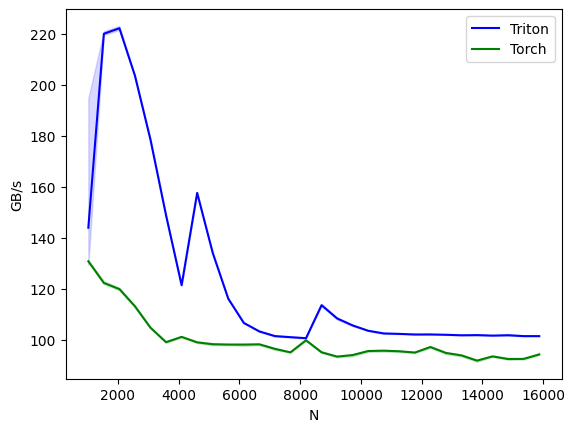

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                      PYTORCH AUTOGRAD INTEGRATION                          ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

class TritonLayerNorm(torch.autograd.Function):
    """
    Custom autograd Function wrapping Triton LayerNorm kernels.
    
    Provides seamless integration with PyTorch's autodiff system while
    leveraging high-performance Triton kernels for computation.
    """
    
    @staticmethod
    def forward(ctx, input_tensor, normalized_shape, gamma, beta, epsilon):
        """Forward pass: compute layer normalization."""
        # Prepare output buffer
        output = torch.empty_like(input_tensor)
        
        # Flatten to 2D for kernel processing
        input_2d = input_tensor.reshape(-1, input_tensor.shape[-1])
        num_rows, num_features = input_2d.shape
        
        # Allocate statistics buffers
        mean_cache = torch.empty((num_rows,), dtype=torch.float32, device=input_tensor.device)
        rstd_cache = torch.empty((num_rows,), dtype=torch.float32, device=input_tensor.device)
        
        # Compute block size (limited by shared memory: 64KB)
        MAX_FEATURES_IN_SMEM = 65536 // input_tensor.element_size()
        TILE_SIZE = min(MAX_FEATURES_IN_SMEM, triton.next_power_of_2(num_features))
        
        if num_features > TILE_SIZE:
            raise RuntimeError(f"Feature dimension {num_features} exceeds 64KB SRAM limit")
        
        # Warp count heuristic
        num_warps = min(max(TILE_SIZE // 256, 1), 8)
        
        # Launch forward kernel
        layer_norm_forward_kernel[(num_rows,)](
            input_2d, output, gamma, beta, mean_cache, rstd_cache,
            input_2d.stride(0), num_features, epsilon,
            TILE_SIZE=TILE_SIZE, num_warps=num_warps, num_ctas=1
        )
        
        # Save tensors for backward pass
        ctx.save_for_backward(input_tensor, gamma, beta, mean_cache, rstd_cache)
        ctx.TILE_SIZE = TILE_SIZE
        ctx.num_warps = num_warps
        ctx.epsilon = epsilon
        
        return output
    
    @staticmethod
    def backward(ctx, grad_output):
        """Backward pass: compute gradients."""
        input_tensor, gamma, beta, mean_cache, rstd_cache = ctx.saved_tensors
        num_features = gamma.shape[0]
        
        # Adaptive group size based on feature dimension
        # More groups = finer granularity but more overhead
        if num_features <= 1024:
            NUM_GROUPS = 256
        elif num_features <= 4096:
            NUM_GROUPS = 128
        elif num_features <= 8192:
            NUM_GROUPS = 96
        else:
            NUM_GROUPS = 64
        
        # Allocate gradient buffers
        sync_locks = torch.zeros(2 * NUM_GROUPS, dtype=torch.int32, device=gamma.device)
        partial_dw = torch.zeros((NUM_GROUPS, num_features), dtype=input_tensor.dtype, device=gamma.device)
        partial_db = torch.zeros((NUM_GROUPS, num_features), dtype=input_tensor.dtype, device=gamma.device)
        final_dw = torch.empty((num_features,), dtype=gamma.dtype, device=gamma.device)
        final_db = torch.empty((num_features,), dtype=gamma.dtype, device=gamma.device)
        grad_input = torch.empty_like(grad_output)
        
        # Flatten for kernel processing
        input_2d = input_tensor.reshape(-1, input_tensor.shape[-1])
        num_rows, num_features = input_2d.shape
        
        # Stage 1: Compute dx and accumulate partial dw/db
        layer_norm_backward_dx_kernel[(num_rows,)](
            grad_input, grad_output, partial_dw, partial_db,
            input_tensor, gamma, mean_cache, rstd_cache, sync_locks,
            input_2d.stride(0), num_features,
            NUM_GROUPS=NUM_GROUPS, FEATURE_BLOCK=ctx.TILE_SIZE,
            num_warps=ctx.num_warps
        )
        
        # Stage 2: Reduce partial gradients to final values
        reduction_grid = lambda meta: (triton.cdiv(num_features, meta['FEATURE_BLOCK']),)
        layer_norm_backward_dwdb_kernel[reduction_grid](
            partial_dw, partial_db, final_dw, final_db,
            min(NUM_GROUPS, num_rows), num_features,
            GROUP_BLOCK=32, FEATURE_BLOCK=128, num_ctas=1
        )
        
        return grad_input, None, final_dw, final_db, None


# Convenience function for easier invocation
triton_layer_norm = TritonLayerNorm.apply


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                         CORRECTNESS VALIDATION                             ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

def validate_layer_norm_implementation(batch_size, feature_dim, precision, epsilon=1e-5, device=COMPUTE_DEVICE):
    """
    Comprehensive validation of Triton LayerNorm against PyTorch reference.
    
    Tests both forward and backward passes for numerical correctness.
    """
    tensor_shape = (batch_size, feature_dim)
    param_shape = (feature_dim,)
    
    # Initialize parameters and inputs
    gamma = torch.rand(param_shape, dtype=precision, device=device, requires_grad=True)
    beta = torch.rand(param_shape, dtype=precision, device=device, requires_grad=True)
    x = -2.3 + 0.5 * torch.randn(tensor_shape, dtype=precision, device=device)
    upstream_grad = 0.1 * torch.randn_like(x)
    x.requires_grad_(True)
    
    # ─── Forward Pass Comparison ───
    triton_output = triton_layer_norm(x, param_shape, gamma, beta, epsilon)
    pytorch_output = torch.nn.functional.layer_norm(x, param_shape, gamma, beta, epsilon).to(precision)
    
    # ─── Backward Pass (Triton) ───
    triton_output.backward(upstream_grad, retain_graph=True)
    triton_dx, triton_dw, triton_db = [t.grad.clone() for t in [x, gamma, beta]]
    x.grad, gamma.grad, beta.grad = None, None, None
    
    # ─── Backward Pass (PyTorch) ───
    pytorch_output.backward(upstream_grad, retain_graph=True)
    pytorch_dx, pytorch_dw, pytorch_db = [t.grad.clone() for t in [x, gamma, beta]]
    
    # ─── Numerical Comparison ───
    tolerance = {'atol': 1e-2, 'rtol': 0}
    assert torch.allclose(triton_output, pytorch_output, **tolerance), "Forward pass mismatch!"
    assert torch.allclose(triton_dx, pytorch_dx, **tolerance), "Input gradient mismatch!"
    assert torch.allclose(triton_db, pytorch_db, **tolerance), "Bias gradient mismatch!"
    assert torch.allclose(triton_dw, pytorch_dw, **tolerance), "Weight gradient mismatch!"
    
    print(f"✓ Validation PASSED for shape ({batch_size}, {feature_dim})")


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                         PERFORMANCE BENCHMARKING                           ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[512 * i for i in range(2, 32)],
        line_arg='provider',
        line_vals=['triton', 'torch'] + (['apex'] if APEX_AVAILABLE else []),
        line_names=['Triton', 'Torch'] + (['Apex'] if APEX_AVAILABLE else []),
        styles=[('blue', '-'), ('green', '-'), ('orange', '-')],
        ylabel='GB/s',
        plot_name='layer-norm-backward',
        args={'M': 4096, 'dtype': torch.float16, 'mode': 'backward'},
    )
)
def benchmark_layer_norm(M, N, dtype, provider, mode='backward', eps=1e-5, device=COMPUTE_DEVICE):
    """
    Benchmark layer normalization performance across implementations.
    
    Measures effective memory bandwidth (GB/s) for fair comparison.
    """
    # Setup tensors
    tensor_shape = (M, N)
    param_shape = (N,)
    
    gamma = torch.rand(param_shape, dtype=dtype, device=device, requires_grad=True)
    beta = torch.rand(param_shape, dtype=dtype, device=device, requires_grad=True)
    x = -2.3 + 0.5 * torch.randn(tensor_shape, dtype=dtype, device=device)
    upstream_grad = 0.1 * torch.randn_like(x)
    x.requires_grad_(True)
    
    quantiles = [0.5, 0.2, 0.8]
    
    def execute_forward():
        if provider == "triton":
            return triton_layer_norm(x, param_shape, gamma, beta, eps)
        elif provider == "torch":
            return torch.nn.functional.layer_norm(x, param_shape, gamma, beta, eps)
        elif provider == "apex":
            apex_ln = apex.normalization.FusedLayerNorm(param_shape).to(x.device).to(x.dtype)
            return apex_ln(x)
    
    # Benchmark based on mode
    if mode == 'forward':
        bandwidth_calc = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
        ms, min_ms, max_ms = triton.testing.do_bench(execute_forward, quantiles=quantiles, rep=500)
    elif mode == 'backward':
        y = execute_forward()
        bandwidth_calc = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: y.backward(upstream_grad, retain_graph=True),
            quantiles=quantiles,
            grad_to_none=[x],
            rep=500
        )
    
    return bandwidth_calc(ms), bandwidth_calc(max_ms), bandwidth_calc(min_ms)


# ═══════════════════════════════════════════════════════════════════════════════
# EXECUTE VALIDATION AND BENCHMARKS
# ═══════════════════════════════════════════════════════════════════════════════

validate_layer_norm_implementation(1151, 8192, torch.float16)
benchmark_layer_norm.run(save_path='.', print_data=True)

---

##  Summary & References

### Key Implementation Insights

| Aspect | Technique Used |
|--------|----------------|
| **Forward fusion** | Single-pass mean/variance with online accumulation |
| **Backward dx** | Fused computation with cached statistics |
| **Parameter gradients** | Lock-based parallel reduction across rows |
| **Memory efficiency** | Streaming through large feature dimensions |

### Performance Characteristics

- **Backward pass** is the primary optimization target (3x memory traffic vs forward)
- **Parallel reduction** with GROUP_SIZE_M buffers enables high throughput
- **Lock contention** managed via adaptive group sizing

### Academic Reference

> **Ba, J. L., Kiros, J. R., & Hinton, G. E.** (2016). *Layer Normalization*. arXiv:1607.06450

---

*Workshop complete. These kernels are production-ready for feature dimensions ≤ 64KB.*

